## 전세 평당 전세금 예측 모델

- 서울 전세 데이터를 분석하고 **평당 전세금**을 예측하는 머신러닝 모델 제작
- **타겟 변수**: 평당 전세금 (만원)
- **계산 공식**: 전세금 / 전용면적(평)

---
## 1. 라이브러리 임포트

In [1]:
# 데이터 처리
import pandas as pd
import numpy as np
import re
import time
import json
from datetime import datetime

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


---
## 2️. 한글 폰트 설정 (그래프용)

In [2]:
# Windows 환경에서 한글 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

print("✅ 한글 폰트 설정 완료")

✅ 한글 폰트 설정 완료


---
## 3️. 데이터 로드

통합 CSV 파일에서 **전세 데이터만** 필터링합니다.

In [3]:
# CSV 파일 경로 (각자 환경에 맞게 수정)
data_path = "C:\\dev\\SKN18-FINAL-1TEAM\\data\\통합.csv"

# 데이터 로드
df = pd.read_csv(data_path, encoding="utf-8")
print(f"전체 데이터: {len(df):,}건")

# 전세 데이터만 필터링
df_jeonse = df[df['거래_정보.거래방식'].str.contains('전세', na=False)].copy()
print(f"전세 데이터: {len(df_jeonse):,}건")

# 처음 5개 행 확인
# df_jeonse.head()

전체 데이터: 9,915건
전세 데이터: 1,965건


---
## 4️. 전세금 추출

"1억 2,000만원" 같은 한국어 금액을 **만원 단위 숫자**로 변환합니다.

In [4]:
def parse_korean_money(text):
    """
    한국 화폐 단위를 만원 단위 숫자로 변환
    예: "1억 2,000만원" -> 12000
    """
    if pd.isna(text):
        return 0
    
    # 불필요한 문자 제거
    text = text.replace(",", "").strip()
    text = re.sub(r"[^\d억만]", "", text)
    
    # "억" 단위 처리
    if "억" in text:
        parts = text.split("억")
        eok = int(parts[0]) if parts[0] else 0
        man = 0
        if len(parts) > 1 and "만" in parts[1]:
            man = int(parts[1].replace("만", ""))
        return eok * 10000 + man
    
    # 숫자만 있는 경우
    numbers = re.findall(r"\d+", text)
    if numbers:
        return int(numbers[0])
    
    return 0


# 전세금 추출
df_jeonse["전세금"] = df_jeonse["거래_정보.거래방식"].apply(parse_korean_money)

print(f"전세금 범위: {df_jeonse['전세금'].min():,.0f} ~ {df_jeonse['전세금'].max():,.0f} 만원")
print(f"평균 전세금: {df_jeonse['전세금'].mean():,.0f} 만원")

전세금 범위: 2,500 ~ 170,000 만원
평균 전세금: 21,092 만원


---
## 5️. 전용면적 추출 및 평당 전세금 계산

### 단계:
1. "30m2/38.68m2" → 전용면적 30㎡ 추출
2. ㎡를 평으로 변환 (1평 = 3.3㎡)
3. **평당 전세금 = 전세금 / 전용면적(평)**

In [5]:
def extract_area(value):
    """
    전용/공급면적에서 전용면적(㎡)만 추출
    예: "30m2/38.68m2" -> 30.0
    """
    if pd.isna(value):
        return None
    try:
        text = str(value).replace(" ", "").strip()
        area_str = text.split('/')[0].replace("m2", "")
        return float(area_str)
    except:
        return None


# 전용면적 추출 및 변환
df_jeonse["전용면적_m2"] = df_jeonse["매물_정보.전용/공급면적"].apply(extract_area)
df_jeonse["전용면적_평"] = df_jeonse["전용면적_m2"] / 3.3

# 평당 전세금 계산 (타겟 변수)
df_jeonse["평당가"] = df_jeonse["전세금"] / df_jeonse["전용면적_평"].replace(0, np.nan)

# 결측치 및 0 이하 값 제거
df_jeonse = df_jeonse.dropna(subset=["전용면적_평", "평당가"])
df_jeonse = df_jeonse[df_jeonse["평당가"] > 0]

print(f"유효 데이터: {len(df_jeonse):,}건")
print(f"평당 전세금 범위: {df_jeonse['평당가'].min():,.0f} ~ {df_jeonse['평당가'].max():,.0f} 만원")
print(f"평균 평당 전세금: {df_jeonse['평당가'].mean():,.0f} 만원")

유효 데이터: 1,961건
평당 전세금 범위: 333 ~ 22,685 만원
평균 평당 전세금: 2,688 만원


---
## 6️. 이상치 제거 (IQR 방법)

극단적으로 비정상적인 값을 제거하여 모델 성능을 향상시킵니다.

In [6]:
# IQR(사분위 범위) 계산
Q1 = df_jeonse['평당가'].quantile(0.25)
Q3 = df_jeonse['평당가'].quantile(0.75)
IQR = Q3 - Q1

# 이상치 범위 설정
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
before_count = len(df_jeonse)
df_jeonse = df_jeonse[
    (df_jeonse['평당가'] >= lower_bound) & 
    (df_jeonse['평당가'] <= upper_bound)
]
after_count = len(df_jeonse)

print(f"이상치 제거: {before_count:,}건 → {after_count:,}건 ({before_count - after_count}건 제거)")

이상치 제거: 1,961건 → 1,942건 (19건 제거)


## 7. 추가 특성 추출

In [7]:
# 1. 관리비 추출 ("관리비 5만원" -> 5)
def extract_management_fee(value):
    if pd.isna(value):
        return 0
    match = re.search(r'(\d+)\s*만원', str(value))
    return int(match.group(1)) if match else 0

df_jeonse["관리비"] = df_jeonse["거래_정보.관리비"].apply(extract_management_fee)


# 2. 층 정보 추출 ("3층/10층" -> 3)
def extract_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    match = re.search(r'-?\d+', parts[0])
    return int(match.group(0)) if match else None

df_jeonse["층"] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_floor)


# 3. 방/욕실 개수 추출
room_info = df_jeonse["매물_정보.방/욕실개수"].str.extract(r'(?P<방수>\d+)개/(?P<욕실수>\d+)개')
df_jeonse["방수"] = room_info["방수"].astype(float)


# 4. 구/동 추출
def extract_gu_dong(addr):
    if pd.isna(addr):
        return (None, None)
    addr = str(addr).strip()
    gu_match = re.search(r'(\S+구)', addr)
    dong_match = re.search(r'(\S+?\d*(동|가))', addr)
    gu = gu_match.group(1) if gu_match else None
    dong = dong_match.group(1) if dong_match else None
    return (gu, dong)

df_jeonse["구"], df_jeonse["동"] = zip(*df_jeonse["주소_정보.전체주소"].apply(extract_gu_dong))


# 결측치 제거
df_jeonse = df_jeonse.dropna(subset=["구", "동", "층", "방수"])

print(f"최종 데이터: {len(df_jeonse):,}건")

최종 데이터: 1,326건


---
## 8️. 데이터 시각화 (EDA)

### 8-1. 평당 전세금 분포

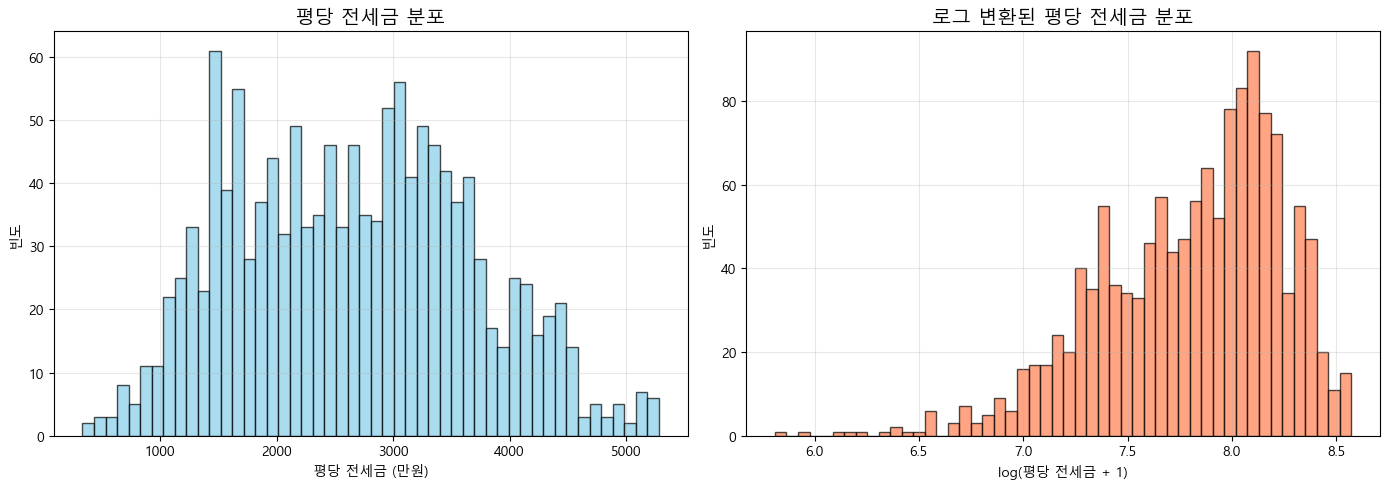

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본 분포
axes[0].hist(df_jeonse["평당가"], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title("평당 전세금 분포", fontsize=14)
axes[0].set_xlabel("평당 전세금 (만원)")
axes[0].set_ylabel("빈도")
axes[0].grid(True, alpha=0.3)

# 로그 변환 분포
axes[1].hist(np.log1p(df_jeonse["평당가"]), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title("로그 변환된 평당 전세금 분포", fontsize=14)
axes[1].set_xlabel("log(평당 전세금 + 1)")
axes[1].set_ylabel("빈도")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8-2. 구별 평균 평당 전세금 TOP 10

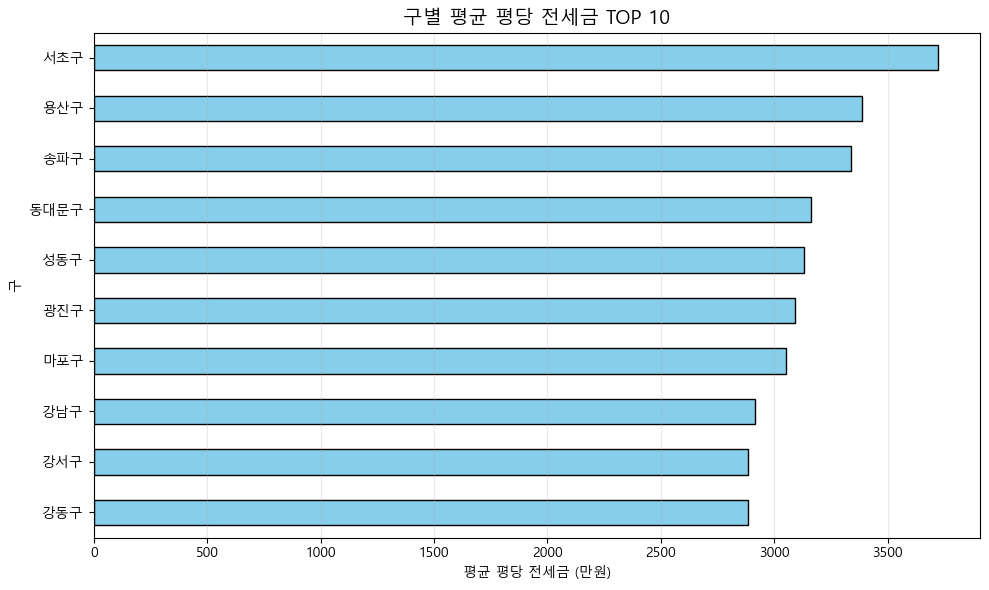


구별 평균 평당 전세금 TOP 10:
 1. 서초구: 3,722 만원
 2. 용산구: 3,387 만원
 3. 송파구: 3,338 만원
 4. 동대문구: 3,162 만원
 5. 성동구: 3,132 만원
 6. 광진구: 3,093 만원
 7. 마포구: 3,051 만원
 8. 강남구: 2,915 만원
 9. 강서구: 2,886 만원
10. 강동구: 2,885 만원


In [9]:
# 구별 평균 계산
gu_avg = df_jeonse.groupby("구")["평당가"].mean().sort_values(ascending=False).head(10)

# 막대 그래프
plt.figure(figsize=(10, 6))
gu_avg.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("구별 평균 평당 전세금 TOP 10", fontsize=14)
plt.xlabel("평균 평당 전세금 (만원)")
plt.ylabel("구")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# 순위 출력
print("\n구별 평균 평당 전세금 TOP 10:")
for idx, (gu, price) in enumerate(gu_avg.items(), 1):
    print(f"{idx:2d}. {gu}: {price:,.0f} 만원")

---
## 9️, 특성 엔지니어링 (Feature Engineering)

모델 성능을 높이기 위한 추가 특성을 생성합니다.

In [10]:
# ===== 추가 중요 피처 생성 =====

# 5. 전체층수 추출 ("3층/10층" -> 10)
def extract_total_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    if len(parts) < 2:
        return None
    match = re.search(r'\d+', parts[1])
    return int(match.group(0)) if match else None

df_jeonse["전체층수"] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_total_floor)


# 6. 층비율 (해당층/전체층)
df_jeonse["층비율"] = df_jeonse.apply(
    lambda row: row["층"] / row["전체층수"] if pd.notna(row["전체층수"]) and row["전체층수"] > 0 else None,
    axis=1
)

# 9. 방향 (남향계열 여부: 남, 남동, 남서)
def is_south_facing(value):
    if pd.isna(value):
        return 0
    text = str(value).lower()
    return 1 if any(keyword in text for keyword in ['남', 'south']) else 0

df_jeonse["is_남향계열"] = df_jeonse["매물_정보.주실기준/방향"].apply(is_south_facing)


# 10. 난방방식 (개별난방 여부)
def is_individual_heating(value):
    if pd.isna(value):
        return 0
    text = str(value)
    return 1 if '개별' in text else 0

df_jeonse["난방_개별"] = df_jeonse["매물_정보.난방방식"].apply(is_individual_heating)


print("=" * 80)
print("✅ 추가 피처 생성 완료")
print("=" * 80)
print(f"전체 데이터: {len(df_jeonse):,}건")
print(f"전체층수 결측치: {df_jeonse['전체층수'].isna().sum()}건")
print(f"층비율 결측치: {df_jeonse['층비율'].isna().sum()}건")
print(f"남향계열: {df_jeonse['is_남향계열'].sum()}건")
print(f"개별난방: {df_jeonse['난방_개별'].sum()}건")

✅ 추가 피처 생성 완료
전체 데이터: 1,326건
전체층수 결측치: 0건
층비율 결측치: 0건
남향계열: 862건
개별난방: 1238건


In [11]:
# ===== 1. 옵션 개수 계산 (추가_옵션에서 추출) =====
def count_options(value):
    """
    추가_옵션 컬럼에서 옵션 개수 계산
    예: "엘리베이터|전세자금대출|주차가능" -> 3
    """
    if pd.isna(value):
        return 0
    
    # "|"로 분리하여 개수 계산
    options = str(value).split('|')
    # 빈 문자열 제거
    options = [opt.strip() for opt in options if opt.strip()]
    return len(options)

df_jeonse["옵션개수"] = df_jeonse["추가_옵션"].apply(count_options)


# ===== 2. 평당 방수 (방 개수 / 전용면적_평) =====
if "방수" in df_jeonse.columns and "전용면적_평" in df_jeonse.columns:
    denom = df_jeonse["전용면적_평"].replace(0, np.nan)
    df_jeonse["평당_방수"] = df_jeonse["방수"] / denom
else:
    df_jeonse["평당_방수"] = np.nan


# ===== 3. 평당 관리비 (관리비 / 전용면적_평) =====
if "관리비" in df_jeonse.columns and "전용면적_평" in df_jeonse.columns:
    denom = df_jeonse["전용면적_평"].replace(0, np.nan)
    df_jeonse["평당_관리비"] = df_jeonse["관리비"] / denom
else:
    df_jeonse["평당_관리비"] = np.nan


print("=" * 80)
print("✅ 특성 엔지니어링 완료")
print("=" * 80)
print(f"옵션개수 통계:")
print(f"  평균: {df_jeonse['옵션개수'].mean():.2f}개")
print(f"  중앙값: {df_jeonse['옵션개수'].median():.0f}개")
print(f"  최대: {df_jeonse['옵션개수'].max():.0f}개")
print(f"  0개인 매물: {(df_jeonse['옵션개수'] == 0).sum()}건")
print("=" * 80)

✅ 특성 엔지니어링 완료
옵션개수 통계:
  평균: 4.37개
  중앙값: 5개
  최대: 7개
  0개인 매물: 52건


In [12]:
current_year = datetime.now().year

def extract_approval_year(value):
    if pd.isna(value):
        return None
    digits = re.sub(r"[^0-9]", "", str(value))
    if len(digits) >= 4:
        year = int(digits[:4])
        if 1900 <= year <= current_year:
            return year
    return None

df_jeonse["사용승인년도"] = df_jeonse["매물_정보.사용승인일"].apply(extract_approval_year)
df_jeonse["건축연차"] = df_jeonse["사용승인년도"].apply(
    lambda year: current_year - year if pd.notna(year) else None
)
df_jeonse["건축연차"] = df_jeonse["건축연차"].fillna(df_jeonse["건축연차"].median())

df_jeonse["노후_15년이상"] = df_jeonse["건축연차"].apply(lambda age: 1 if age >= 15 else 0)

remodel_keywords = [kw.lower() for kw in [
    "리모델링", "올리모델링", "올수리", "풀리모델링",
    "부분수리", "전면보수", "새단장", "외벽보수", "엘리베이터교체"
]]
remodel_text = (
    df_jeonse["상세_설명"].fillna('') + "|" + df_jeonse["추가_옵션"].fillna('')
).str.replace(" ", "", regex=False).str.lower()
df_jeonse["리모델링여부"] = remodel_text.apply(
    lambda text: 1 if any(keyword in text for keyword in remodel_keywords) else 0
)

print("✅ 건축연차/리모델링 피처 생성 완료")


✅ 건축연차/리모델링 피처 생성 완료


In [13]:
option_keywords = {
    "옵션_주차가능": ["주차가능", "전용주차", "지하주차장", "주차장"],
    "옵션_엘리베이터": ["엘리베이터", "승강기"],
    "옵션_전세자금대출": ["전세자금대출", "전세대출", "대출가능"],
    "옵션_무인경비": ["경비실", "무인경비", "보안시스템"],
    "옵션_빌트인": ["빌트인", "붙박이장", "시스템에어컨"]
}

option_text = df_jeonse["추가_옵션"].fillna('').str.lower()
for col, keywords in option_keywords.items():
    lowered = [kw.lower() for kw in keywords]
    df_jeonse[col] = option_text.apply(
        lambda text, kw=lowered: 1 if any(k in text for k in kw) else 0
    )

print("✅ 옵션 세분화 피처 생성 완료")


✅ 옵션 세분화 피처 생성 완료


---
## 10. ML용 데이터 준비

모델 학습에 사용할 특성만 선택합니다.

In [14]:
# ===== 5. ML용 데이터셋 구성 =====

# 타깃(평당가) 컬럼
target_col = "평당가"

feature_cols = [
    "전용면적_평",
    "관리비",
    "평당_방수",
    "평당_관리비",
    "구",
    "동",
    "옵션개수",
    "전체층수",
    "층비율",
    "is_남향계열",
    "난방_개별",

    # 추가
    "건축연차",
    "노후_15년이상",
    "리모델링여부",
    "옵션_주차가능",
    "옵션_엘리베이터",
    "옵션_전세자금대출",
    "옵션_무인경비",
    "옵션_빌트인",
]



# 타깃 + 피처 모두 있는 행만 사용 (결측치 제거)
df_ml = df_jeonse[[target_col] + feature_cols].dropna().copy()

print(f"ML 데이터 크기: {df_ml.shape}")
print(f"타깃 컬럼: {target_col}")
print(f"특성 개수: {len(feature_cols)}개")
print(f"데이터 개수: {len(df_ml):,}건")
print("\n💡 다음 셀에서 LabelEncoder 적용 예정 (월세 모델과 동일한 방식)")


ML 데이터 크기: (1326, 20)
타깃 컬럼: 평당가
특성 개수: 19개
데이터 개수: 1,326건

💡 다음 셀에서 LabelEncoder 적용 예정 (월세 모델과 동일한 방식)


In [15]:
# X: 입력 특성, y: 타겟 변수
X = df_ml.drop(columns=["평당가"])
y = df_ml["평당가"]

# ===== LabelEncoder 적용 (월세 모델과 동일한 방식) =====
print("\n" + "=" * 80)
print("🔒 LabelEncoder 적용 (구, 동)")
print("=" * 80)

label_cols = ["구", "동"]

for col in label_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"✅ '{col}' 인코딩 완료: {X[col].nunique()}개 카테고리")

print("=" * 80)

# 80:20 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n학습 데이터: {len(X_train):,}건")
print(f"테스트 데이터: {len(X_test):,}건")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")


🔒 LabelEncoder 적용 (구, 동)
✅ '구' 인코딩 완료: 27개 카테고리
✅ '동' 인코딩 완료: 140개 카테고리

학습 데이터: 1,060건
테스트 데이터: 266건
Train shape: (1060, 19)
Test shape: (266, 19)


---
## 1️1. 모델 학습 (XGBoost)

### 로그 변환
평당가의 분포가 치우쳐 있으므로 **로그 변환**을 통해 정규화합니다.

In [16]:
# 타겟 변수 로그 변환
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("✅ 로그 변환 완료")

✅ 로그 변환 완료


In [17]:
# XGBoost 모델 생성
model = XGBRegressor(
    n_estimators=1800,        # 트리 개수
    learning_rate=0.018,      # 학습률
    max_depth=10,             # 트리 최대 깊이
    subsample=0.88,           # 데이터 샘플링 비율
    colsample_bytree=0.88,    # 특성 샘플링 비율
    min_child_weight=3,       # 과적합 방지
    gamma=0.03,               # 노드 분할 최소 손실
    reg_alpha=0.03,           # L1 정규화
    reg_lambda=1,             # L2 정규화
    random_state=42,
    n_jobs=-1,                # 모든 CPU 코어 사용
    tree_method='hist'        # 빠른 학습 방법
)

# 모델 학습
print("\n🚀 모델 학습 시작...")
model.fit(X_train, y_train_log)
print("✅ 모델 학습 완료!")


🚀 모델 학습 시작...
✅ 모델 학습 완료!


---
## 1️2. 예측 및 평가

### 성능 지표:
- **MAE** (Mean Absolute Error): 평균 절대 오차
- **RMSE** (Root Mean Squared Error): 평균 제곱근 오차
- **R²** (R-squared): 결정계수 (1에 가까울수록 좋음)
- **MAPE** (Mean Absolute Percentage Error): 평균 절대 백분율 오차

In [18]:
# 예측 (로그 변환된 값)
y_pred_log = model.predict(X_test)

# 원래 스케일로 복원
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

# 성능 지표 계산
mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)
mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100

# 결과 출력
print("\n" + "=" * 80)
print("📊 전세 평당 전세금 예측 모델 성능")
print("=" * 80)
print(f"MAE   : {mae:,.2f} 만원  (평균적으로 {mae:,.0f}만원 오차)")
print(f"RMSE  : {rmse:,.2f} 만원")
print(f"R²    : {r2:.4f}  (1에 가까울수록 좋음)")
print(f"MAPE  : {mape:.2f}%  (평균 {mape:.1f}% 오차율)")


📊 전세 평당 전세금 예측 모델 성능
MAE   : 355.02 만원  (평균적으로 355만원 오차)
RMSE  : 481.49 만원
R²    : 0.7816  (1에 가까울수록 좋음)
MAPE  : 19.16%  (평균 19.2% 오차율)


---
## 1️3. 결과 시각화

### 13-1. 실제값 vs 예측값

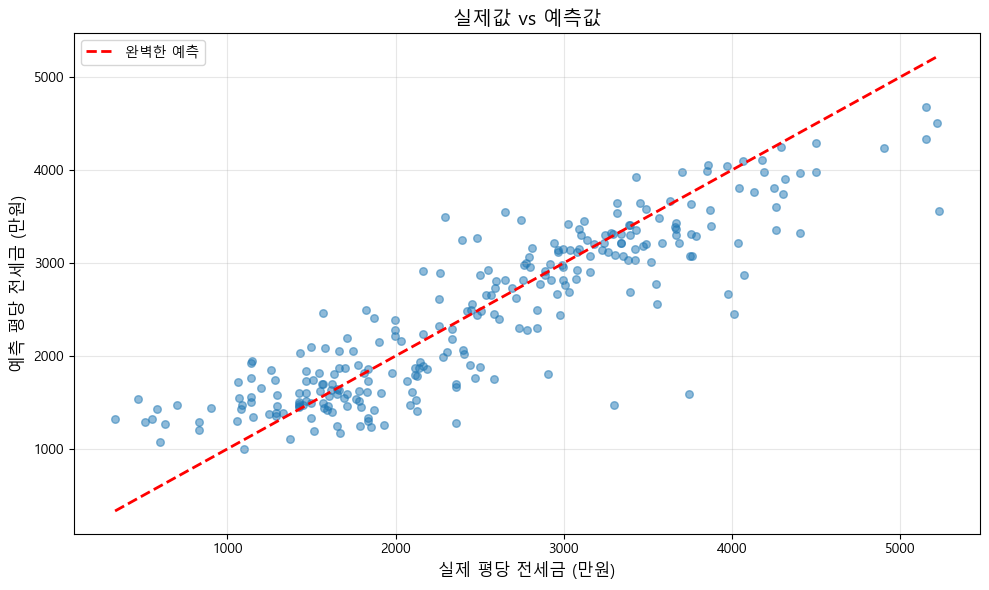

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.5, s=30)

# 대각선 (완벽한 예측)
max_val = max(y_test_orig.max(), y_pred.max())
min_val = min(y_test_orig.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측')

plt.xlabel("실제 평당 전세금 (만원)", fontsize=12)
plt.ylabel("예측 평당 전세금 (만원)", fontsize=12)
plt.title("실제값 vs 예측값", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13-2. 오차율 분포

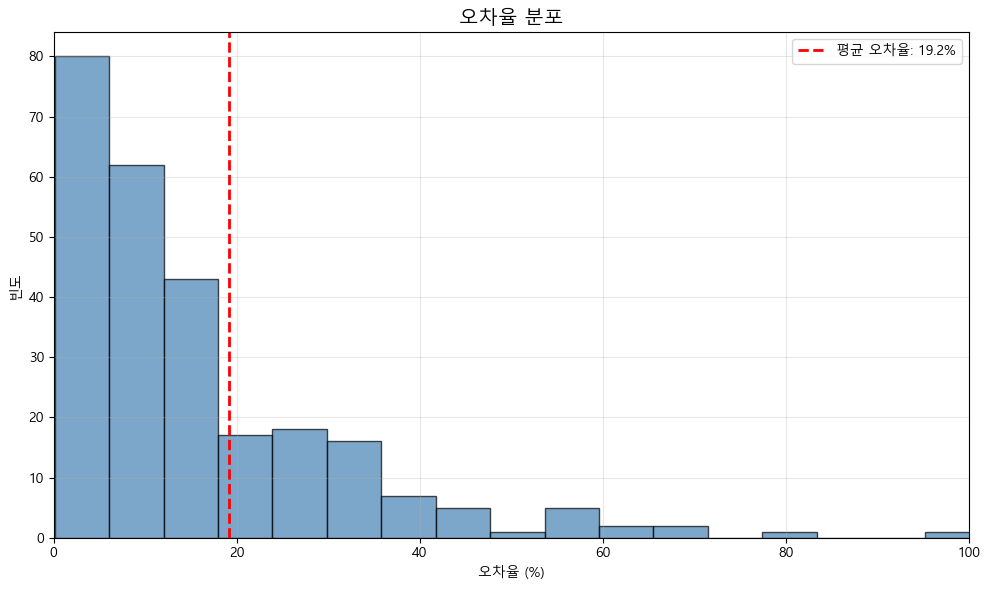

In [20]:
# 오차율 계산
error_rate = np.abs((y_test_orig - y_pred) / y_test_orig) * 100

plt.figure(figsize=(10, 6))
plt.hist(error_rate, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlim(0, 100)
plt.axvline(mape, color='red', linestyle='--', linewidth=2, 
            label=f'평균 오차율: {mape:.1f}%')
plt.title("오차율 분포", fontsize=14)
plt.xlabel("오차율 (%)")
plt.ylabel("빈도")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 13-3. 특성 중요도

C:\Users\Playdata\AppData\Local\Temp\ipykernel_28016\109552324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')


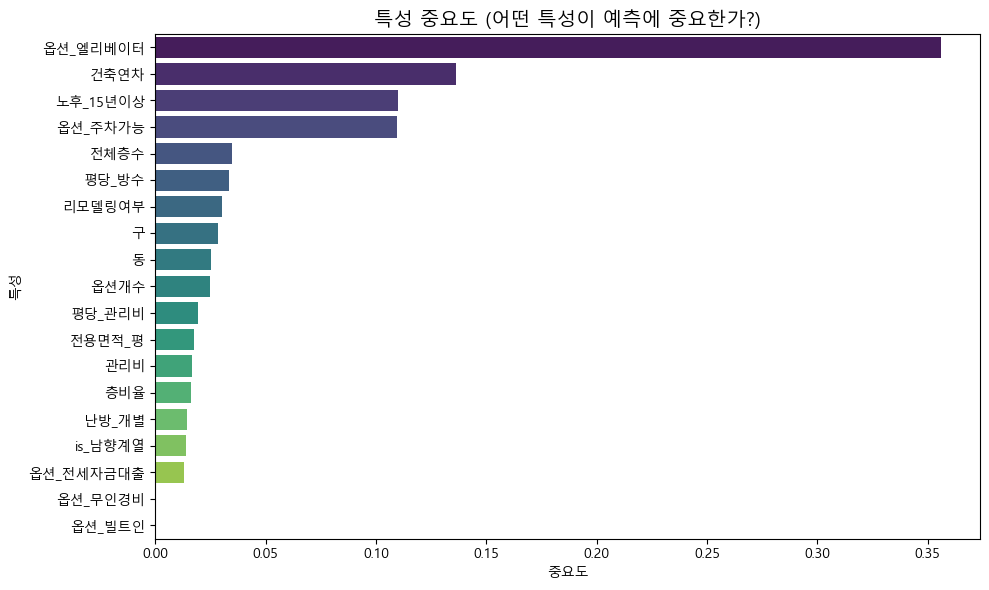


특성 중요도 순위:
옵션_엘리베이터             : 0.3559
건축연차                 : 0.1364
노후_15년이상             : 0.1101
옵션_주차가능              : 0.1095
전체층수                 : 0.0348
평당_방수                : 0.0335
리모델링여부               : 0.0301
구                    : 0.0286
동                    : 0.0252
옵션개수                 : 0.0249
평당_관리비               : 0.0195
전용면적_평               : 0.0176
관리비                  : 0.0165
층비율                  : 0.0161
난방_개별                : 0.0144
is_남향계열              : 0.0140
옵션_전세자금대출            : 0.0129
옵션_무인경비              : 0.0000
옵션_빌트인               : 0.0000


In [21]:
# 특성 중요도 계산
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')
plt.title("특성 중요도 (어떤 특성이 예측에 중요한가?)", fontsize=14)
plt.xlabel("중요도")
plt.ylabel("특성")
plt.tight_layout()
plt.show()

# 순위 출력
print("\n특성 중요도 순위:")
for idx, row in feature_importance.iterrows():
    print(f"{row['특성']:20s} : {row['중요도']:.4f}")

In [22]:
import shap

# SHAP Explainer 생성 (XGBoost 전용)
explainer = shap.TreeExplainer(model)

# 테스트 데이터에서 샘플링 (계산 속도를 위해 100개만 사용)
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42)

# SHAP 값 계산
print("🔍 SHAP 값 계산 중... (시간이 걸릴 수 있습니다)")
shap_values = explainer.shap_values(X_test_sample)
print("✅ SHAP 계산 완료!")

🔍 SHAP 값 계산 중... (시간이 걸릴 수 있습니다)
✅ SHAP 계산 완료!


#### SHAP Feature Importance (개별 예측 설명)

 어떤 feature / 전체 데이터 가 가장 영향을 많이 줬는가

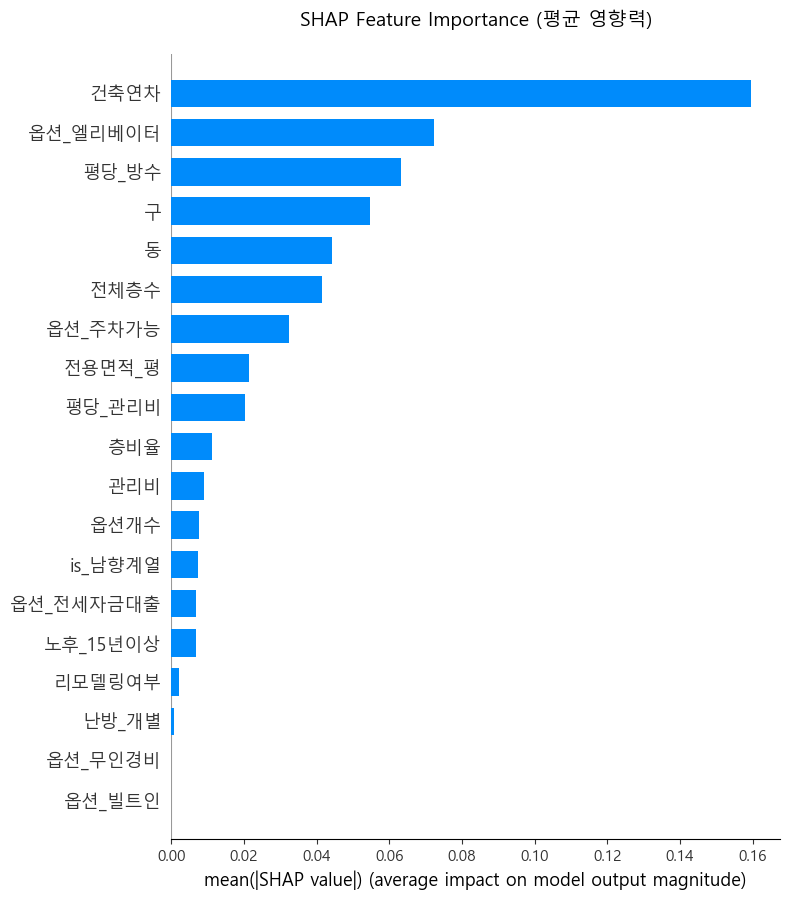

In [23]:
import shap
# SHAP Bar Plot (평균 절댓값)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (평균 영향력)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#### shap summary plot
각 feature가 값이 커질수록 가격을 올릴지/내릴지 방향과 분산을 보여줌

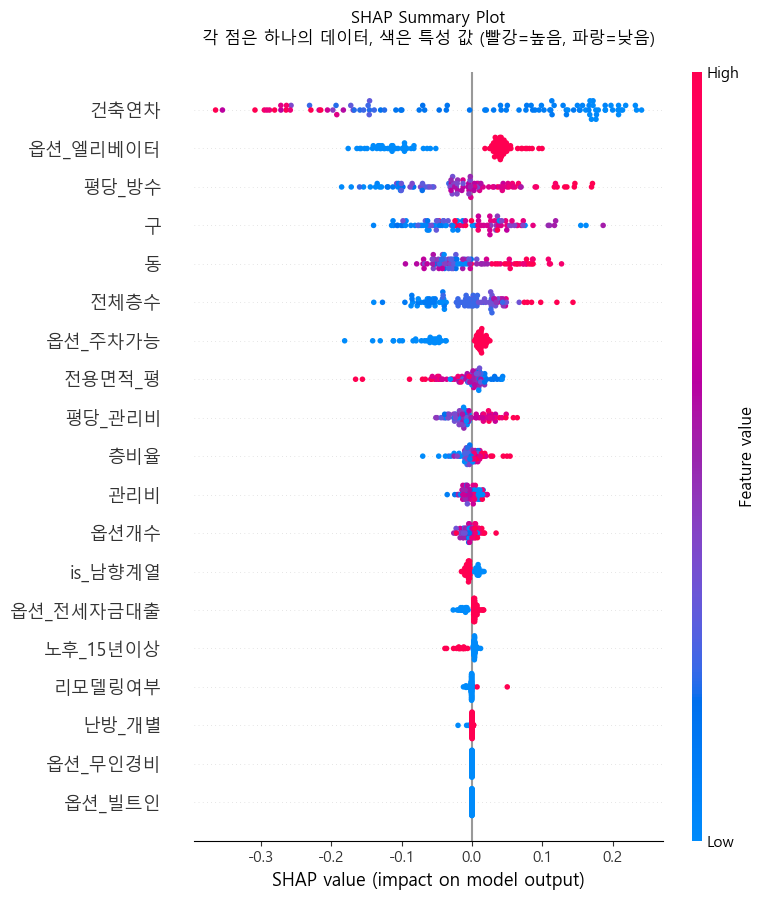


📖 해석 방법:
- 위에 있을수록 중요한 특성
- 오른쪽으로 퍼져있을수록 예측에 큰 영향
- 빨간색: 특성 값이 높을 때
- 파란색: 특성 값이 낮을 때


In [24]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="dot", show=False)
plt.title("SHAP Summary Plot\n각 점은 하나의 데이터, 색은 특성 값 (빨강=높음, 파랑=낮음)", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

print("\n📖 해석 방법:")
print("- 위에 있을수록 중요한 특성")
print("- 오른쪽으로 퍼져있을수록 예측에 큰 영향")
print("- 빨간색: 특성 값이 높을 때")
print("- 파란색: 특성 값이 낮을 때")

---
## 1️5. 다양한 모델 성능 비교

여러 머신러닝 모델을 학습하여 성능을 비교합니다.
- **XGBoost**: 현재 사용 중인 모델
- **LightGBM**: 빠른 학습 속도와 높은 성능
- **CatBoost**: 범주형 변수 처리에 강점
- **RandomForest**: 앙상블 기법의 기본 모델
- **GradientBoosting**: 전통적인 부스팅 모델

In [25]:
# # 여러 모델 정의
# models = {
#     'XGBoost': XGBRegressor(
#         n_estimators=1800,
#         learning_rate=0.018,
#         max_depth=10,
#         subsample=0.88,
#         colsample_bytree=0.88,
#         min_child_weight=3,
#         gamma=0.03,
#         reg_alpha=0.03,
#         reg_lambda=1,
#         random_state=42,
#         n_jobs=-1,
#         tree_method='hist'
#     ),
#     'LightGBM': LGBMRegressor(
#         n_estimators=1800,
#         learning_rate=0.018,
#         max_depth=10,
#         subsample=0.88,
#         colsample_bytree=0.88,
#         min_child_weight=3,
#         reg_alpha=0.03,
#         reg_lambda=1,
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     ),
#     'CatBoost': CatBoostRegressor(
#         iterations=1800,
#         learning_rate=0.018,
#         depth=10,
#         subsample=0.88,
#         reg_lambda=1,
#         random_state=42,
#         verbose=0
#     ),
#     'RandomForest': RandomForestRegressor(
#         n_estimators=500,
#         max_depth=15,
#         min_samples_split=5,
#         min_samples_leaf=2,
#         random_state=42,
#         n_jobs=-1
#     ),
#     'GradientBoosting': GradientBoostingRegressor(
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=8,
#         subsample=0.88,
#         random_state=42
#     )
# }

# # 결과 저장용 리스트
# results = []

# print("=" * 80)
# print("🚀 다양한 모델 학습 및 평가 시작")
# print("=" * 80)

# # 각 모델 학습 및 평가
# for model_name, model in models.items():
#     print(f"\n📌 {model_name} 모델 학습 중...")
    
#     # 학습 시간 측정
#     start_time = time.time()
    
#     # 모델 학습
#     model.fit(X_train, y_train_log)
    
#     # 예측
#     y_pred_log = model.predict(X_test)
#     y_pred = np.expm1(y_pred_log)
    
#     # 학습 시간
#     training_time = time.time() - start_time
    
#     # 성능 지표 계산
#     mae = mean_absolute_error(y_test_orig, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
#     r2 = r2_score(y_test_orig, y_pred)
#     mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100
    
#     # 결과 저장
#     results.append({
#         '모델': model_name,
#         'MAE': mae,
#         'RMSE': rmse,
#         'R²': r2,
#         'MAPE(%)': mape,
#         '학습시간(초)': training_time
#     })
    
#     print(f"✅ {model_name} 완료 - R²: {r2:.4f}, MAE: {mae:.2f}, 학습시간: {training_time:.2f}초")

# print("\n" + "=" * 80)
# print("✅ 모든 모델 학습 완료!")
# print("=" * 80)

In [26]:
# 여러 모델 정의
models = {
        'LightGBM': LGBMRegressor(
            n_estimators=2500,          # 1800 → 2500
            learning_rate=0.012,       # 0.018 → 0.012

            max_depth= -1,             # 10 → -1(제한 없음), 대신 num_leaves로 제어
            num_leaves=64,             # 2^depth 수준: 31~127 근처가 무난
            min_data_in_leaf=40,       # 리프 최소 데이터 수 (과적합 방지용)
            subsample=0.8,             # 0.88 → 0.8
            colsample_bytree=0.8,      # 0.88 → 0.8

            reg_alpha=0.1,             # 0.03 → 0.1
            reg_lambda=1.2,            # 1 → 1.2

            min_child_weight=5,        # 3 → 5 (LightGBM에도 있음)
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        'RandomForest': RandomForestRegressor(
            n_estimators=800,         # 500 → 800 (앙상블 강화)
            max_depth=18,             # 15 → 18 (조금 더 유연하게)
            min_samples_split=4,      # 5 → 4 (좀 더 잘게 나누기)
            min_samples_leaf=2,       # 그대로 유지
            max_features='sqrt',      # 기본 auto 대신 sqrt로 변경(트리 다양성 ↑)
            random_state=42,
            n_jobs=-1
        ),

    'XGBoost': XGBRegressor(
        n_estimators=3000,          # 2500 → 3000
        learning_rate=0.01,        # 0.012 → 0.01

        max_depth=6,               # 7 → 6 (조금 더 단순하게)
        subsample=0.8,
        colsample_bytree=0.8,

        min_child_weight=6,        # 5 → 6 (리프 최소 가중치↑)
        gamma=0.2,                 # 0.1 → 0.2 (쓸데없는 분할 감소)

        reg_alpha=0.3,             # 0.1 → 0.3 (L1 규제 강화)
        reg_lambda=1.5,            # 1.2 → 1.5 (L2 규제 강화)

        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    ),

    'CatBoost': CatBoostRegressor(
        iterations=2500,          # 1800 → 2500
        learning_rate=0.012,      # 0.018 → 0.012
        depth=7,                  # 8~10보다 6~8 구간이 많이 쓰임

        # 규제
        l2_leaf_reg=4.0,          # 3~7 사이 실험 추천 (reg_lambda 대체 파라미터)
        random_strength=1.5,      # 1~2: 트리 다양성↑ → 과적합 완화
        bagging_temperature=0.7,  # 0~1: 샘플링 노이즈 추가

        subsample=0.8,
        loss_function='RMSE',
        random_state=42,
        verbose=0
    ),

    'GradientBoosting': GradientBoostingRegressor(
        # 더 많은 트리 + 더 작은 learning rate
        n_estimators=3000,        # 2000 → 3000
        learning_rate=0.007,      # 0.01 → 0.007

        # 트리 더 얕게
        max_depth=3,              # 4 → 3

        # Stochastic Gradient Boosting 강하게
        subsample=0.8,            # 그대로
        max_features='sqrt',      # 추가: 특성 일부만 사용해 다양성↑

        # 규제(복잡한 리프 방지)
        min_samples_split=5,      # 4 → 5
        min_samples_leaf=5,       # 2 → 5

        random_state=42
    )
}


# 결과 저장용 리스트
results = []

print("=" * 80)
print("🚀 다양한 모델 학습 및 평가 시작")
print("=" * 80)

# 각 모델 학습 및 평가
for model_name, model in models.items():
    print(f"\n📌 {model_name} 모델 학습 중...")
    
    # 학습 시간 측정
    start_time = time.time()
    
    # 모델 학습
    model.fit(X_train, y_train_log)
    
    # 예측
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    
    # 학습 시간
    training_time = time.time() - start_time
    
    # 성능 지표 계산
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test_orig, y_pred)
    mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100
    
    # 결과 저장
    results.append({
        '모델': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE(%)': mape,
        '학습시간(초)': training_time
    })
    
    print(f"✅ {model_name} 완료 - R²: {r2:.4f}, MAE: {mae:.2f}, 학습시간: {training_time:.2f}초")

print("\n" + "=" * 80)
print("✅ 모든 모델 학습 완료!")
print("=" * 80)

🚀 다양한 모델 학습 및 평가 시작

📌 LightGBM 모델 학습 중...
✅ LightGBM 완료 - R²: 0.7866, MAE: 349.20, 학습시간: 1.18초

📌 RandomForest 모델 학습 중...
✅ RandomForest 완료 - R²: 0.7646, MAE: 370.50, 학습시간: 0.72초

📌 XGBoost 모델 학습 중...
✅ XGBoost 완료 - R²: 0.7706, MAE: 381.12, 학습시간: 0.80초

📌 CatBoost 모델 학습 중...
✅ CatBoost 완료 - R²: 0.8119, MAE: 331.04, 학습시간: 4.44초

📌 GradientBoosting 모델 학습 중...
✅ GradientBoosting 완료 - R²: 0.8063, MAE: 342.96, 학습시간: 1.90초

✅ 모든 모델 학습 완료!


### 15-1. 모델 성능 비교 테이블

In [27]:
# 결과를 데이터프레임으로 변환
df_results = pd.DataFrame(results)

# R² 기준으로 정렬 (내림차순)
df_results = df_results.sort_values('R²', ascending=False)

print("\n" + "=" * 100)
print("📊 모델 성능 비교 (R² 기준 정렬)")
print("=" * 100)
print(df_results.to_string(index=False))
print("=" * 100)

# 최고 성능 모델 표시
best_model = df_results.iloc[0]
print(f"\n🏆 최고 성능 모델: {best_model['모델']}")
print(f"   - R²: {best_model['R²']:.4f}")
print(f"   - MAE: {best_model['MAE']:.2f} 만원")
print(f"   - RMSE: {best_model['RMSE']:.2f} 만원")
print(f"   - MAPE: {best_model['MAPE(%)']:.2f}%")
print(f"   - 학습시간: {best_model['학습시간(초)']:.2f}초")


📊 모델 성능 비교 (R² 기준 정렬)
              모델        MAE       RMSE       R²   MAPE(%)  학습시간(초)
        CatBoost 331.044991 446.846457 0.811856 18.226898 4.436681
GradientBoosting 342.963580 453.452900 0.806252 18.203595 1.897736
        LightGBM 349.198793 475.872576 0.786620 18.812620 1.181713
         XGBoost 381.117461 493.416541 0.770596 20.110713 0.795317
    RandomForest 370.504608 499.845309 0.764580 20.664867 0.722527

🏆 최고 성능 모델: CatBoost
   - R²: 0.8119
   - MAE: 331.04 만원
   - RMSE: 446.85 만원
   - MAPE: 18.23%
   - 학습시간: 4.44초


### 15-2. 모델 성능 비교 시각화

In [28]:
# 실험 결과 저장 함수
import os

def save_experiment_log(results_list, feature_cols, model_params, save_dir='../experiments'):
    """
    실험 결과를 로그로 저장
    
    Parameters:
    - results_list: 모델 결과 리스트
    - feature_cols: 사용한 특성 목록
    - model_params: 모델별 파라미터 딕셔너리
    - save_dir: 저장 디렉토리
    """
    # 디렉토리 생성
    os.makedirs(save_dir, exist_ok=True)
    
    # 타임스탬프
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # 1. 성능 결과를 CSV로 저장
    df_log = pd.DataFrame(results_list)
    csv_path = os.path.join(save_dir, f'experiment_{timestamp}.csv')
    df_log.to_csv(csv_path, index=False, encoding='utf-8-sig')
    print(f"✅ 성능 결과 저장: {csv_path}")
    
    # 2. 상세 로그를 JSON으로 저장
    log_data = {
        'timestamp': timestamp,
        'dataset_info': {
            'total_samples': len(X),
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'n_features': len(feature_cols),
            'features': feature_cols
        },
        'model_parameters': model_params,
        'results': results_list
    }
    
    json_path = os.path.join(save_dir, f'experiment_{timestamp}.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=2, ensure_ascii=False)
    print(f"✅ 상세 로그 저장: {json_path}")
    
    return timestamp

print("✅ 실험 로깅 함수 정의 완료")

✅ 실험 로깅 함수 정의 완료


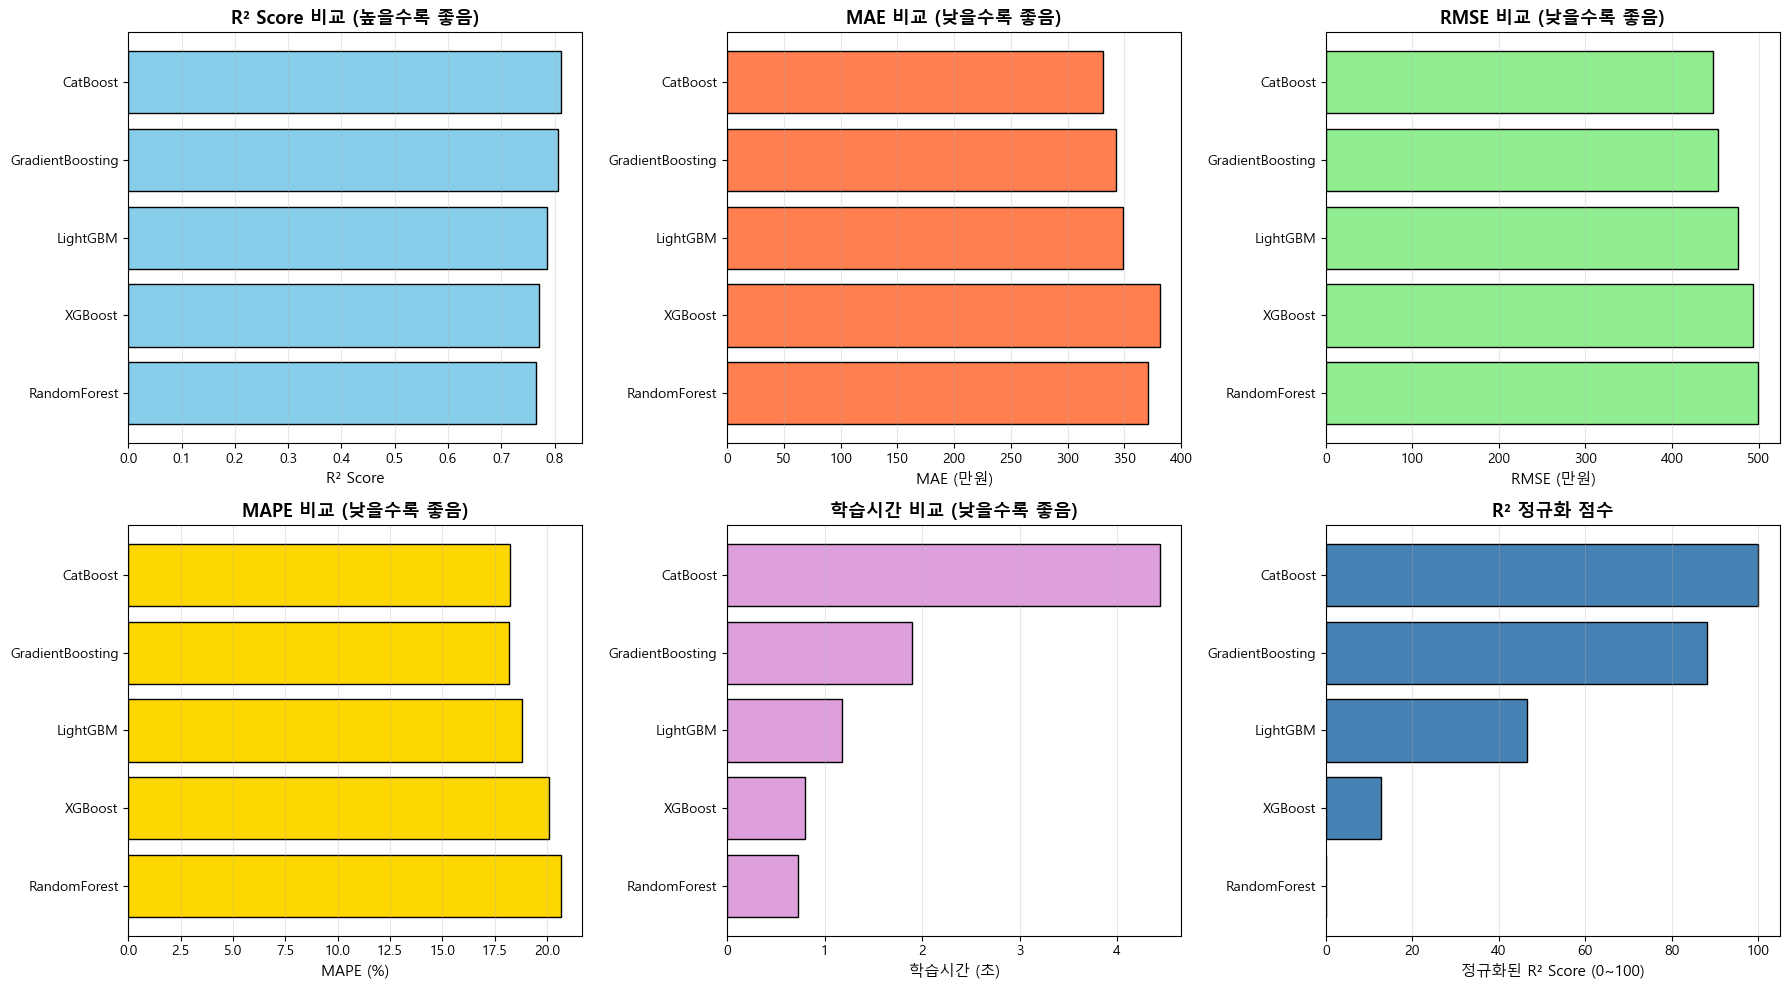

In [29]:
# 성능 지표 비교 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. R² 비교
axes[0, 0].barh(df_results['모델'], df_results['R²'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('R² Score', fontsize=11)
axes[0, 0].set_title('R² Score 비교 (높을수록 좋음)', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].invert_yaxis()

# 2. MAE 비교
axes[0, 1].barh(df_results['모델'], df_results['MAE'], color='coral', edgecolor='black')
axes[0, 1].set_xlabel('MAE (만원)', fontsize=11)
axes[0, 1].set_title('MAE 비교 (낮을수록 좋음)', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].invert_yaxis()

# 3. RMSE 비교
axes[0, 2].barh(df_results['모델'], df_results['RMSE'], color='lightgreen', edgecolor='black')
axes[0, 2].set_xlabel('RMSE (만원)', fontsize=11)
axes[0, 2].set_title('RMSE 비교 (낮을수록 좋음)', fontsize=13, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3, axis='x')
axes[0, 2].invert_yaxis()

# 4. MAPE 비교
axes[1, 0].barh(df_results['모델'], df_results['MAPE(%)'], color='gold', edgecolor='black')
axes[1, 0].set_xlabel('MAPE (%)', fontsize=11)
axes[1, 0].set_title('MAPE 비교 (낮을수록 좋음)', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].invert_yaxis()

# 5. 학습시간 비교
axes[1, 1].barh(df_results['모델'], df_results['학습시간(초)'], color='plum', edgecolor='black')
axes[1, 1].set_xlabel('학습시간 (초)', fontsize=11)
axes[1, 1].set_title('학습시간 비교 (낮을수록 좋음)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

# 6. 종합 점수 (R² 기준 정규화 막대 그래프)
# R²를 0~100 스케일로 변환
r2_normalized = (df_results['R²'] - df_results['R²'].min()) / (df_results['R²'].max() - df_results['R²'].min()) * 100
axes[1, 2].barh(df_results['모델'], r2_normalized, color='steelblue', edgecolor='black')
axes[1, 2].set_xlabel('정규화된 R² Score (0~100)', fontsize=11)
axes[1, 2].set_title('R² 정규화 점수', fontsize=13, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3, axis='x')
axes[1, 2].invert_yaxis()

plt.tight_layout()
plt.show()

### 15-3. 레이더 차트로 종합 비교

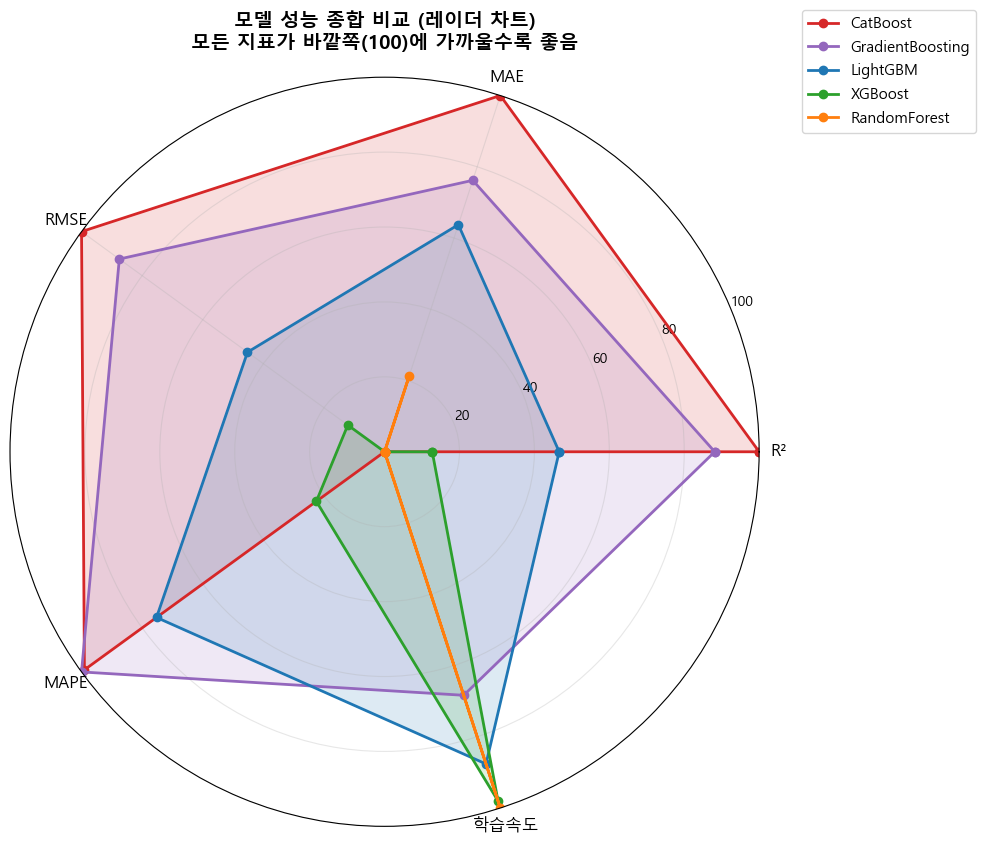


💡 레이더 차트 해석:
   - 모든 지표가 0~100으로 정규화되었습니다
   - 바깥쪽(100)에 가까울수록 좋은 성능을 의미합니다
   - 넓은 면적을 차지하는 모델일수록 종합적으로 우수합니다


In [30]:
# 레이더 차트를 위한 데이터 정규화
from math import pi

# 정규화 함수 (0~100 스케일)
def normalize(series, reverse=False):
    """
    reverse=True: 낮을수록 좋은 지표 (MAE, RMSE, MAPE, 학습시간)
    reverse=False: 높을수록 좋은 지표 (R²)
    """
    if reverse:
        # 낮을수록 좋은 지표는 역순으로 정규화
        return (series.max() - series) / (series.max() - series.min()) * 100
    else:
        # 높을수록 좋은 지표는 정순으로 정규화
        return (series - series.min()) / (series.max() - series.min()) * 100

# 각 지표 정규화
df_results['R²_norm'] = normalize(df_results['R²'], reverse=False)
df_results['MAE_norm'] = normalize(df_results['MAE'], reverse=True)
df_results['RMSE_norm'] = normalize(df_results['RMSE'], reverse=True)
df_results['MAPE_norm'] = normalize(df_results['MAPE(%)'], reverse=True)
df_results['학습시간_norm'] = normalize(df_results['학습시간(초)'], reverse=True)

# 레이더 차트 그리기
categories = ['R²', 'MAE', 'RMSE', 'MAPE', '학습속도']
num_vars = len(categories)

# 각도 계산
angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

# 그래프 생성
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# 색상 팔레트
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 각 모델에 대해 레이더 차트 그리기
for idx, row in df_results.iterrows():
    values = [
        row['R²_norm'],
        row['MAE_norm'],
        row['RMSE_norm'],
        row['MAPE_norm'],
        row['학습시간_norm']
    ]
    values += values[:1]  # 닫힌 도형을 만들기 위해
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['모델'], color=colors[idx % len(colors)])
    ax.fill(angles, values, alpha=0.15, color=colors[idx % len(colors)])

# 레이블 설정
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], size=10)
ax.set_title('모델 성능 종합 비교 (레이더 차트)\n모든 지표가 바깥쪽(100)에 가까울수록 좋음', 
             size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 레이더 차트 해석:")
print("   - 모든 지표가 0~100으로 정규화되었습니다")
print("   - 바깥쪽(100)에 가까울수록 좋은 성능을 의미합니다")
print("   - 넓은 면적을 차지하는 모델일수록 종합적으로 우수합니다")

### 15-4. 모델 추천

In [31]:
print("=" * 100)
print("📌 상황별 모델 추천")
print("=" * 100)

# 1. 성능 최우선 (R² 기준)
best_performance = df_results.iloc[0]
print(f"\n🎯 1. 성능 최우선 (R² 최대)")
print(f"   추천: {best_performance['모델']}")
print(f"   이유: R² {best_performance['R²']:.4f}로 가장 높은 예측 정확도")

# 2. 속도 최우선
fastest = df_results.loc[df_results['학습시간(초)'].idxmin()]
print(f"\n⚡ 2. 속도 최우선 (학습시간 최소)")
print(f"   추천: {fastest['모델']}")
print(f"   이유: {fastest['학습시간(초)']:.2f}초로 가장 빠른 학습")
print(f"   성능: R² {fastest['R²']:.4f}")

# 3. 균형잡힌 선택 (종합 점수)
# 정규화된 지표의 평균 계산
df_results['종합점수'] = (
    df_results['R²_norm'] + 
    df_results['MAE_norm'] + 
    df_results['RMSE_norm'] + 
    df_results['MAPE_norm'] + 
    df_results['학습시간_norm']
) / 5

balanced = df_results.loc[df_results['종합점수'].idxmax()]
print(f"\n⚖️  3. 균형잡힌 선택 (종합 점수 최대)")
print(f"   추천: {balanced['모델']}")
print(f"   이유: 종합점수 {balanced['종합점수']:.2f}점으로 성능과 속도 모두 우수")
print(f"   성능: R² {balanced['R²']:.4f}")
print(f"   학습시간: {balanced['학습시간(초)']:.2f}초")

# 4. 프로덕션 추천
print(f"\n🏭 4. 프로덕션 환경 추천")
print(f"   추천: {best_performance['모델']}")
print(f"   이유:")
print(f"      - 가장 높은 예측 정확도 (R²: {best_performance['R²']:.4f})")
print(f"      - 실제 서비스에서는 예측 정확도가 가장 중요")
print(f"      - 학습은 배치로 수행하므로 학습시간은 상대적으로 덜 중요")

print("\n" + "=" * 100)
print("💡 결론:")
print(f"   - 전체적으로 {best_performance['모델']} 모델이 가장 우수한 성능을 보입니다")
print(f"   - MAE {best_performance['MAE']:.2f}만원, R² {best_performance['R²']:.4f}로 실용적인 수준")
print("=" * 100)

📌 상황별 모델 추천

🎯 1. 성능 최우선 (R² 최대)
   추천: CatBoost
   이유: R² 0.8119로 가장 높은 예측 정확도

⚡ 2. 속도 최우선 (학습시간 최소)
   추천: RandomForest
   이유: 0.72초로 가장 빠른 학습
   성능: R² 0.7646

⚖️  3. 균형잡힌 선택 (종합 점수 최대)
   추천: GradientBoosting
   이유: 종합점수 84.05점으로 성능과 속도 모두 우수
   성능: R² 0.8063
   학습시간: 1.90초

🏭 4. 프로덕션 환경 추천
   추천: CatBoost
   이유:
      - 가장 높은 예측 정확도 (R²: 0.8119)
      - 실제 서비스에서는 예측 정확도가 가장 중요
      - 학습은 배치로 수행하므로 학습시간은 상대적으로 덜 중요

💡 결론:
   - 전체적으로 CatBoost 모델이 가장 우수한 성능을 보입니다
   - MAE 331.04만원, R² 0.8119로 실용적인 수준


### 15-5. 실험 결과 저장

In [32]:
# 15-5. 실험 결과 저장 & 개선된 파라미터로 최종 재학습

# 1) 모델 파라미터 정리 및 실험 로그 저장
model_params = {name: model.get_params() for name, model in models.items()}
experiment_id = save_experiment_log(
    results_list=results,
    feature_cols=feature_cols,
    model_params=model_params,
    save_dir="../experiments"
)
print(f"📝 experiment_{experiment_id}.* 파일이 ../experiments 에 저장되었습니다.")

# 2) 최고 성능 모델 선택 후 파라미터 확인
best_model_row = df_results.iloc[0]
best_model_name = best_model_row["모델"]
best_params = model_params[best_model_name]

key_param_names = [
    "n_estimators", "iterations", "learning_rate", "max_depth", "depth",
    "subsample", "colsample_bytree", "min_child_weight", "gamma",
    "reg_alpha", "reg_lambda"
]
param_preview = {k: best_params[k] for k in key_param_names if k in best_params}
print(f"\n🚀 {best_model_name}를 개선된 파라미터로 재학습합니다.")
print(f"   주요 파라미터: {param_preview}")

# 3) 전체 데이터(Log 변환 포함)로 모델 재학습
best_model_cls = models[best_model_name].__class__
final_model = best_model_cls(**best_params)

y_full_log = np.log1p(y)
final_model.fit(X, y_full_log)
print("✅ 전체 데이터 재학습 완료!")

# 4) 샘플 예측으로 sanity check
sample_preds = np.expm1(final_model.predict(X_test.head()))
print("샘플 예측 (만원):", np.round(sample_preds, 2))


✅ 성능 결과 저장: ../experiments\experiment_20251205_224740.csv
✅ 상세 로그 저장: ../experiments\experiment_20251205_224740.json
📝 experiment_20251205_224740.* 파일이 ../experiments 에 저장되었습니다.

🚀 CatBoost를 개선된 파라미터로 재학습합니다.
   주요 파라미터: {'iterations': 2500, 'learning_rate': 0.012, 'depth': 7, 'subsample': 0.8}
✅ 전체 데이터 재학습 완료!
샘플 예측 (만원): [1591.27 1589.85 2457.57 1132.05 1751.93]
